In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv(r"D:\SACHIN RAWAL FILES\Projects\Spam_classifer\spam.csv",encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [13]:
df.shape

(5572, 5)

In [14]:
df = df.drop(columns=[2, 3, 4],axis=1)

ValueError: Cannot specify both 'axis' and 'index'/'columns'

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [16]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5054,ham,Am on a train back from northampton so i'm afr...,NaN,NaN,NaN
4024,ham,&lt;#&gt; in mca. But not conform.,NaN,NaN,NaN
455,ham,Si si. I think ill go make those oreo truffles.,NaN,NaN,NaN
5204,ham,How come she can get it? Should b quite diff t...,NaN,NaN,NaN
2574,spam,Your next amazing xxx PICSFREE1 video will be ...,NaN,NaN,NaN


In [17]:
df.rename(columns={'v1':'Target','v2':'Text'},inplace=True)
df.sample(5)

,Target,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
389,ham,Yup having my lunch buffet now.. U eat already?,NaN,NaN,NaN
1333,ham,"Oh... Icic... K lor, den meet other day...",NaN,NaN,NaN
3540,ham,If you are not coughing then its nothing,NaN,NaN,NaN
3343,ham,Oh great. I.ll disturb him more so that we can...,NaN,NaN,NaN
4690,ham,Surly ill give it to you:-) while coming to re...,NaN,NaN,NaN


In [18]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [19]:
df['Target'] =encoder.fit_transform(df['Target'])
df.sample(5)

,Target,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
3373,0,Also andros ice etc etc,NaN,NaN,NaN
1903,1,Free entry in 2 a weekly comp for a chance to ...,NaN,NaN,NaN
3817,1,74355 XMAS iscoming & ur awarded either å£500 ...,NaN,NaN,NaN
411,0,Cos i want it to be your thing,NaN,NaN,NaN
4777,0,U R THE MOST BEAUTIFUL GIRL IVE EVER SEEN. U R...,NaN,NaN,NaN


In [20]:
df.isnull().sum()

Target           0
Text             0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(403)

In [22]:
df = df.drop_duplicates(keep='first')

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.shape

(5169, 5)

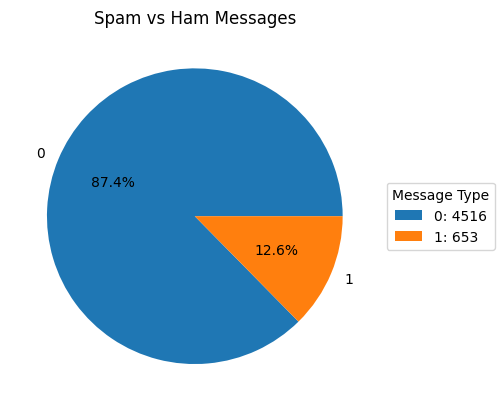

In [25]:
count = df['Target'].value_counts()
plt.pie(count,labels=count.index,autopct='%1.1f%%')
plt.legend(
    [f"{label}: {value}" for label, value in count.items()],
    title="Message Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
plt.title('Spam vs Ham Messages')
plt.show()

In [26]:
import nltk

In [27]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rawal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rawal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rawal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [28]:
df['Num_char'] = df['Text'].apply(len)
df['Num_char']

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: Num_char, Length: 5169, dtype: int64

In [29]:
df['Num_word'] = df['Text'].apply(lambda x :len(nltk.word_tokenize(x)))
df['Num_word']

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: Num_word, Length: 5169, dtype: int64

In [30]:
df['Num_sent'] = df['Text'].apply(lambda x :len(nltk.sent_tokenize(x)))
df['Num_sent']

0       2
1       2
2       2
3       1
4       1
       ..
5567    4
5568    1
5569    2
5570    1
5571    2
Name: Num_sent, Length: 5169, dtype: int64

In [31]:
df.head()

,Target,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4,Num_char,Num_word,Num_sent
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24,2
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37,2
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15,1


In [32]:
df.describe()

,Target,Num_char,Num_word,Num_sent
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.460437,1.965564
std,0.332253,58.236293,13.334441,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [33]:
df[df['Target'] == 0][['Num_char',	'Num_word',	'Num_sent']].describe()
#Not spam

,Num_char,Num_word,Num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.128432,1.820195
std,56.358207,13.504730,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [34]:
df[df['Target'] == 1][['Num_char',	'Num_word',	'Num_sent']].describe()
#Spam

,Num_char,Num_word,Num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.672282,2.970904
std,30.137753,7.010932,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


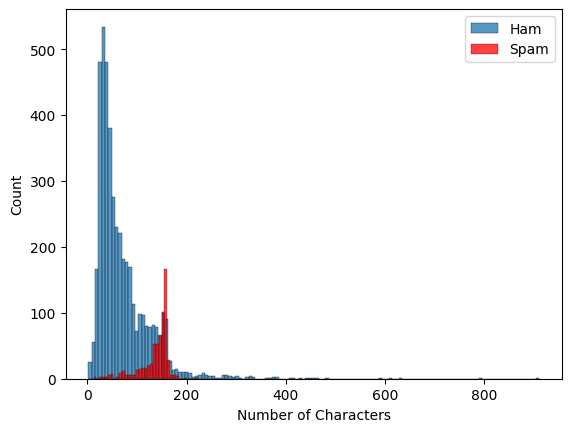

In [35]:
sns.histplot(df[df['Target'] == 0]['Num_char'], label='Ham')
sns.histplot(df[df['Target'] == 1]['Num_char'], color='red', label='Spam')

plt.xlabel('Number of Characters')
plt.ylabel('Count')
plt.legend()
plt.show()

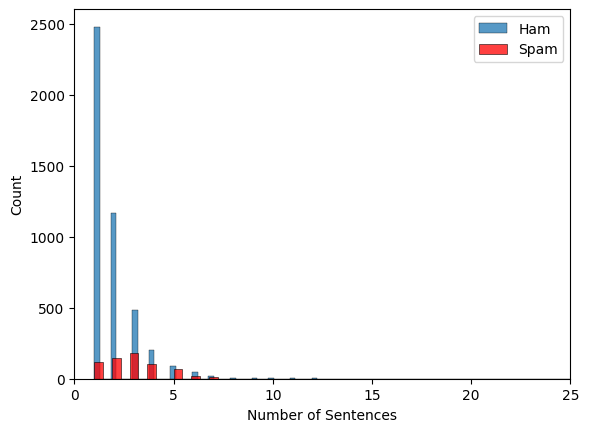

In [36]:
sns.histplot(df[df['Target'] == 0]['Num_sent'], label='Ham')
sns.histplot(df[df['Target'] == 1]['Num_sent'], color='red', label='Spam')
plt.xlim(0, 25)
plt.xlabel('Number of Sentences')
plt.ylabel('Count')
plt.legend()
plt.show()

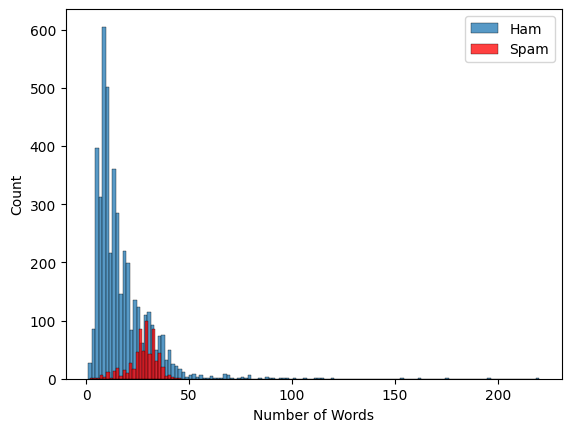

In [37]:
sns.histplot(df[df['Target'] == 0]['Num_word'], label='Ham')
sns.histplot(df[df['Target'] == 1]['Num_word'], color='red', label='Spam')

plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend()
plt.show()

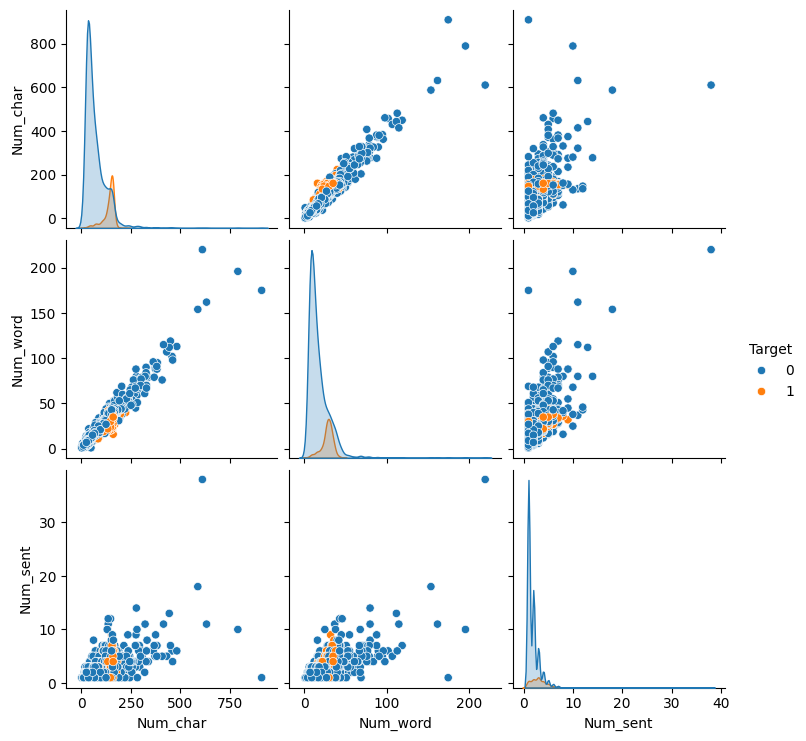

In [38]:
sns.pairplot(df,hue='Target')

<Axes: xlabel='Num_char', ylabel='Density'>

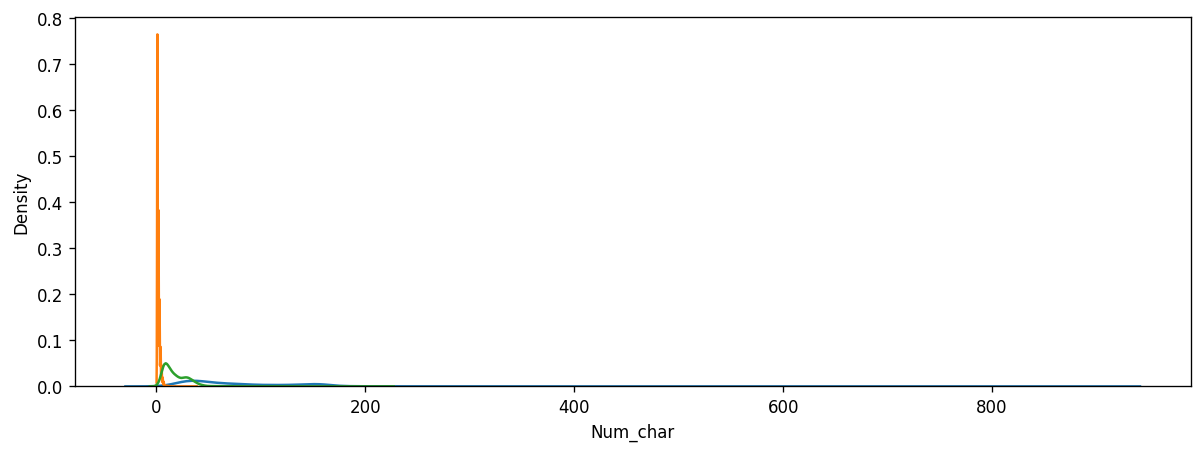

In [39]:
plt.figure(figsize=(12,4),dpi=120)
sns.kdeplot(df['Num_char'])
sns.kdeplot(df['Num_sent'])
sns.kdeplot(df['Num_word'])


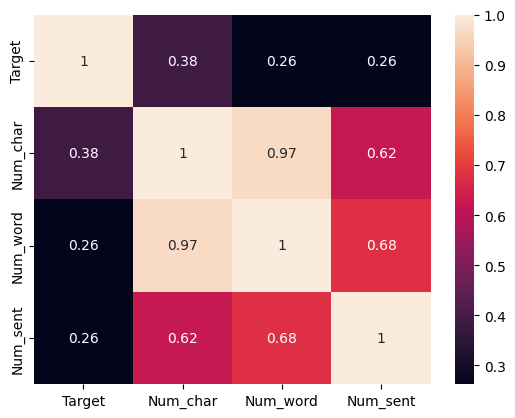

In [40]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [41]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [42]:
ps = PorterStemmer()

In [43]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [44]:
df['Transform_text'] = df['Text'].apply(transform_text)

In [45]:
df.head()

,Target,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4,Num_char,Num_word,Num_sent,Transform_text
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15,1,nah think goe usf live around though


In [52]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

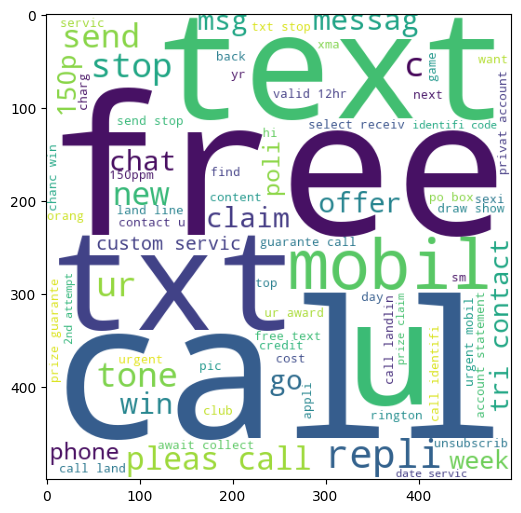

In [57]:
spam = wc.generate(df[df['Target'] == 1]['Transform_text'].str.cat(sep=" "))
plt.figure(figsize=(6,20))
plt.imshow(spam)

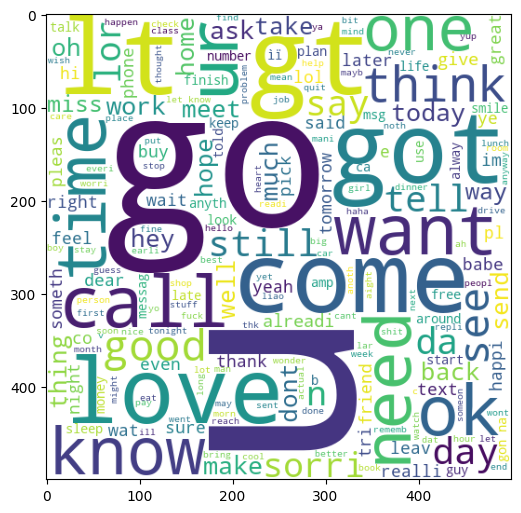

In [58]:
ham = wc.generate(df[df['Target'] == 0]['Transform_text'].str.cat(sep=" "))
plt.figure(figsize=(6,20))
plt.imshow(ham)

In [ ]:
ham_corpus = nltk.word_tokenize(
    ' '.join(df[df['Target'] == 0]['Transform_text'])
)

In [62]:
spam_corpus = nltk.word_tokenize(
    ' '.join(df[df['Target'] == 1]['Transform_text'])
)

C:\Users\rawal\AppData\Local\Temp\ipykernel_12716\2701844168.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp[0], y=temp[1] , palette='rainbow',legend=False)


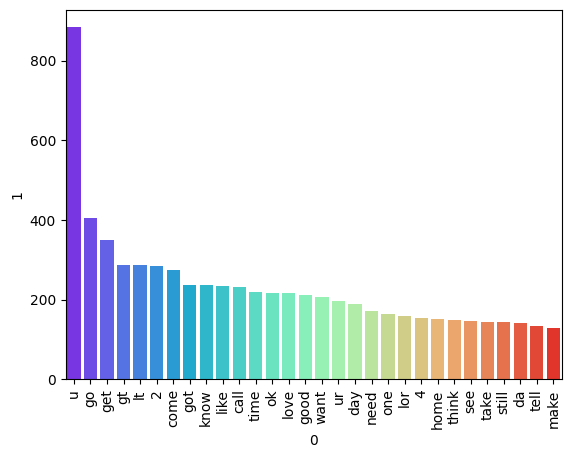

In [78]:
from collections import Counter

temp = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=temp[0], y=temp[1] , palette='rainbow',legend=False)
plt.xticks(rotation=90)
plt.show()

C:\Users\rawal\AppData\Local\Temp\ipykernel_12716\3082760558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp1[0], y=temp1[1] , palette='viridis',legend=False)


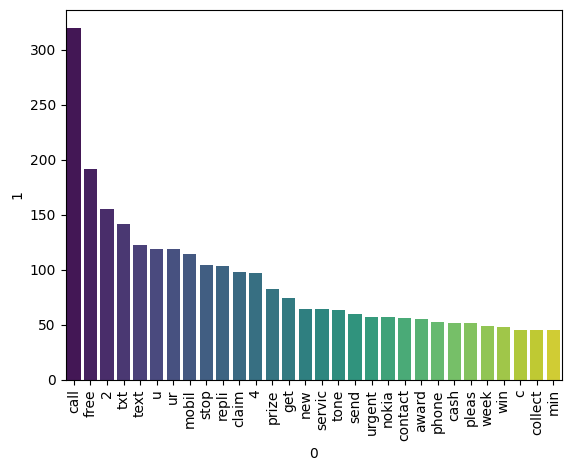

In [79]:
from collections import Counter

temp1 = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=temp1[0], y=temp1[1] , palette='viridis',legend=False)
plt.xticks(rotation=90)
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)

In [113]:
# X = cv.fit_transform(df['Transform_text']).toarray()
X = tfidf.fit_transform(df['Transform_text']).toarray()


In [114]:
X.shape

(5169, 3000)

In [115]:
Y = df['Target'].values


In [116]:
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [117]:
from sklearn.model_selection import train_test_split

In [118]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.2,random_state=3)

In [119]:
from sklearn.naive_bayes import MultinomialNB , GaussianNB , BernoulliNB
from sklearn.metrics import accuracy_score , precision_score , confusion_matrix
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [120]:
model_g = gnb.fit(X_train,Y_train)
pred_1 = model_g.predict(X_test)
print(accuracy_score(Y_test, pred_1))
print(precision_score(Y_test, pred_1))
print(confusion_matrix(Y_test, pred_1))


0.8617021276595744
0.49382716049382713
[[771 123]
 [ 20 120]]


In [121]:
model_m = mnb.fit(X_train,Y_train)
pred_2 = model_m.predict(X_test)
print(accuracy_score(Y_test, pred_2))
print(precision_score(Y_test, pred_2))
print(confusion_matrix(Y_test, pred_2))
# this model provide a high precision == 0
# we select multinomial Naive bayes

0.9700193423597679
1.0
[[894   0]
 [ 31 109]]


In [122]:
model_b = bnb.fit(X_train,Y_train)
pred_3 = model_b.predict(X_test)
print(accuracy_score(Y_test, pred_3))
print(precision_score(Y_test, pred_3))
print(confusion_matrix(Y_test, pred_3))


0.9787234042553191
0.9916666666666667
[[893   1]
 [ 21 119]]


In [123]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))